100%|██████████| 170M/170M [00:05<00:00, 29.2MB/s]


Epoch 1 | Loss: 1.839 | Acc: 34.01%
Epoch 2 | Loss: 1.285 | Acc: 53.38%
Epoch 3 | Loss: 0.974 | Acc: 65.41%
Epoch 4 | Loss: 0.793 | Acc: 72.14%
Epoch 5 | Loss: 0.674 | Acc: 76.44%
Epoch 6 | Loss: 0.592 | Acc: 79.61%
Epoch 7 | Loss: 0.545 | Acc: 81.11%
Epoch 8 | Loss: 0.503 | Acc: 82.55%
Epoch 9 | Loss: 0.483 | Acc: 83.34%
Epoch 10 | Loss: 0.460 | Acc: 84.31%
Epoch 11 | Loss: 0.443 | Acc: 84.91%
Epoch 12 | Loss: 0.421 | Acc: 85.65%
Epoch 13 | Loss: 0.409 | Acc: 85.81%
Epoch 14 | Loss: 0.393 | Acc: 86.63%
Epoch 15 | Loss: 0.379 | Acc: 87.10%
Epoch 16 | Loss: 0.357 | Acc: 87.78%
Epoch 17 | Loss: 0.351 | Acc: 87.98%
Epoch 18 | Loss: 0.337 | Acc: 88.43%
Epoch 19 | Loss: 0.329 | Acc: 88.76%
Epoch 20 | Loss: 0.320 | Acc: 88.98%
Epoch 21 | Loss: 0.304 | Acc: 89.66%
Epoch 22 | Loss: 0.289 | Acc: 90.13%
Epoch 23 | Loss: 0.280 | Acc: 90.38%
Epoch 24 | Loss: 0.267 | Acc: 90.95%
Epoch 25 | Loss: 0.259 | Acc: 91.20%
Epoch 26 | Loss: 0.237 | Acc: 91.90%
Epoch 27 | Loss: 0.235 | Acc: 91.94%
Epoch 28 |

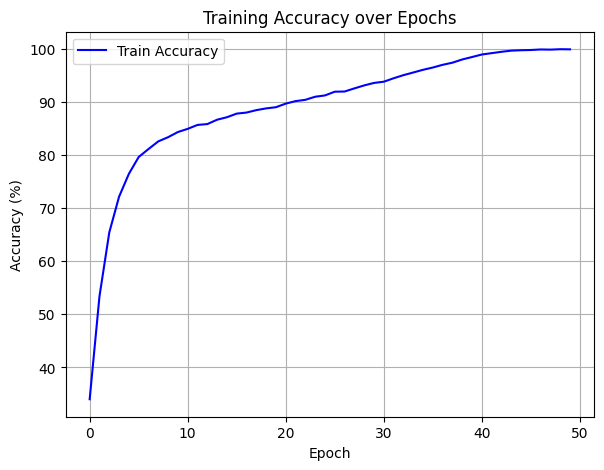

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 配置设备 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# --- 2. 数据预处理 ---
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

# --- 3. 定义模型 ---
def get_model():
    model = resnet18(num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(device)

net = get_model()

# --- 4. 损失函数与优化器 ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# 用于绘图的数据存储
history = {'train_loss': [], 'train_acc': []}

# --- 5. 训练循环 ---
def train(epoch):
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    avg_loss = train_loss / (batch_idx + 1)
    acc = 100. * correct / total

    # 记录数据
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(acc)

    print(f'Epoch {epoch} | Loss: {avg_loss:.3f} | Acc: {acc:.2f}%')

# --- 6. 详细测试函数 (包含类别准确率) ---
def test_and_show_analysis():
    net.eval()
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))

    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = net(inputs)
            _, predicted = outputs.max(1)
            c = (predicted == targets).squeeze()

            for i in range(len(targets)):
                label = targets[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # 打印并收集每个类别的准确率
    print('\nAccuracy of each class:')
    class_accs = {}
    for i in range(10):
        acc = 100 * class_correct[i] / class_total[i]
        class_accs[classes[i]] = acc
        print(f'Accuracy of {classes[i]:5s} : {acc:.2f}%')

    overall_acc = 100 * sum(class_correct) / sum(class_total)
    print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
    return class_accs

# --- 7. 绘图函数 ---
def plot_metrics(history, class_accs):
    plt.figure(figsize=(15, 5))

    # 绘制训练准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
    plt.title('Training Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

# --- 8. 执行流程 ---
if __name__ == '__main__':
    EPOCHS = 50 # 建议运行至少50次以获得ResNet的良好效果
    for epoch in range(1, EPOCHS + 1):
        train(epoch)
        scheduler.step()

    # 获取类别准确率数据
    final_class_accs = test_and_show_analysis()

    # 绘图展示
    plot_metrics(history, final_class_accs)

正在收集测试集预测结果...


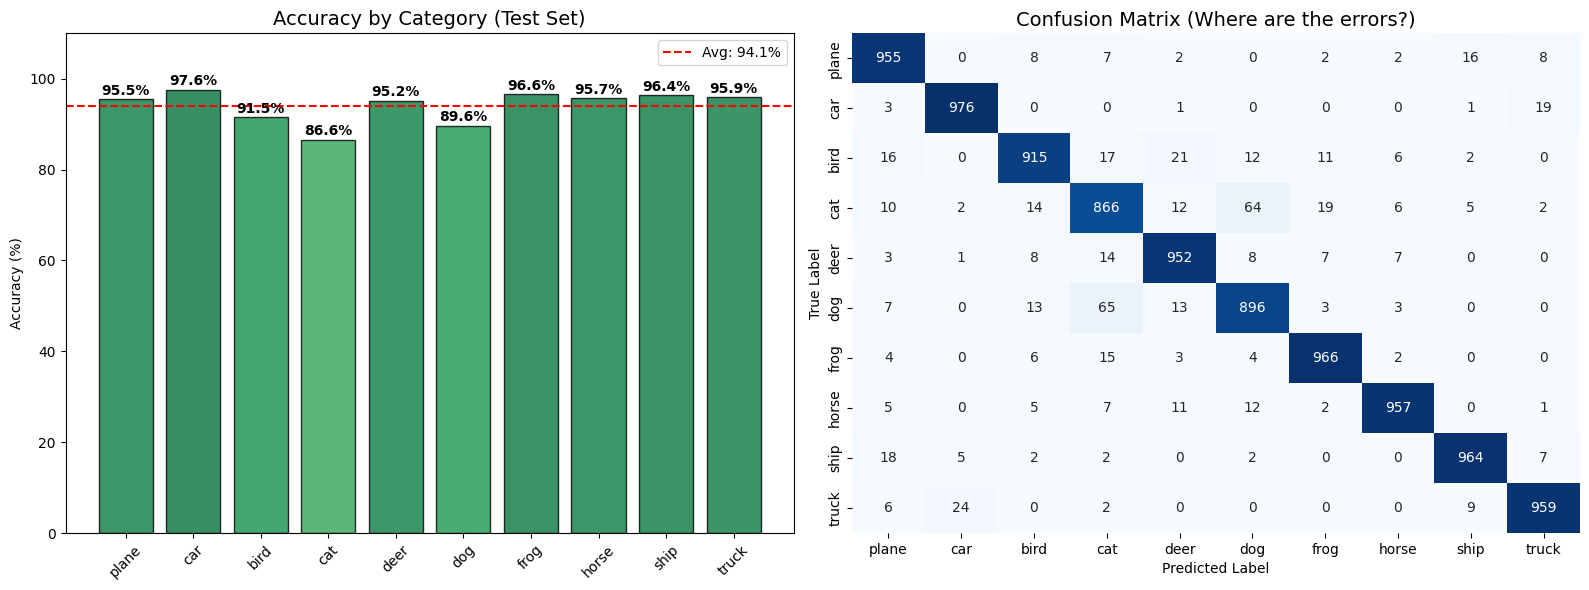

🌟 分析完成！
✅ 表现最好: car (97.60%)
⚠️ 表现最差: cat (86.60%)


In [2]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

def analyze_and_plot_existing_model(model, loader, class_names):
    model.eval()
    all_preds = []
    all_targets = []

    print("正在收集测试集预测结果...")
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # 计算混淆矩阵
    cm = confusion_matrix(all_targets, all_preds)
    # 计算每个类别的准确率
    class_acc = 100 * cm.diagonal() / cm.sum(axis=1)

    # --- 绘图部分 ---
    plt.figure(figsize=(16, 6))

    # 1. 类别准确率条形图
    plt.subplot(1, 2, 1)
    colors = plt.cm.RdYlGn(class_acc / 100) # 越绿准确率越高
    bars = plt.bar(class_names, class_acc, color=colors, edgecolor='black', alpha=0.8)
    plt.axhline(y=np.mean(class_acc), color='red', linestyle='--', label=f'Avg: {np.mean(class_acc):.1f}%')
    plt.title('Accuracy by Category (Test Set)', fontsize=14)
    plt.ylabel('Accuracy (%)')
    plt.ylim(0, 110)
    plt.xticks(rotation=45)
    plt.legend()
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontweight='bold')

    # 2. 混淆矩阵热力图
    plt.subplot(1, 2, 2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.title('Confusion Matrix (Where are the errors?)', fontsize=14)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.tight_layout()
    plt.show()

    # 打印简要总结
    worst_idx = np.argmin(class_acc)
    best_idx = np.argmax(class_acc)
    print(f"🌟 分析完成！")
    print(f"✅ 表现最好: {class_names[best_idx]} ({class_acc[best_idx]:.2f}%)")
    print(f"⚠️ 表现最差: {class_names[worst_idx]} ({class_acc[worst_idx]:.2f}%)")

# 直接调用
analyze_and_plot_existing_model(net, testloader, classes)

In [3]:
import torch
from pathlib import Path

def model_profile(model, inputs):
    # 1. 计算参数量
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # 2. 估计 FLOPs (针对卷积层和全连接层的简化估算)
    # 这能让你知道模型做一次预测需要多少次数学运算
    print(f"\n" + "="*30)
    print(f"📊 模型性能简报")
    print(f"="*30)
    print(f"总参数量 (Total Params):   {total_params:,}")
    print(f"可训练参数 (Trainable):    {trainable_params:,}")
    print(f"模型文件大小 (Est. Size):  {total_params * 4 / (1024**2):.2f} MB")

    # 保存模型
    save_path = 'cifar10_resnet18_94acc.pth'
    torch.save(model.state_dict(), save_path)
    print(f"💾 模型已保存至: {Path(save_path).absolute()}")
    print(f"="*30)

# 创建一个模拟输入 (Batch Size=1, Channel=3, Width=32, Height=32)
dummy_input = torch.randn(1, 3, 32, 32).to(device)
model_profile(net, dummy_input)



📊 模型性能简报
总参数量 (Total Params):   11,173,962
可训练参数 (Trainable):    11,173,962
模型文件大小 (Est. Size):  42.63 MB
💾 模型已保存至: /content/cifar10_resnet18_94acc.pth
